# Used Car Price Analysis & Classification

**Jonathan Zada · Solo academic project · Grade: 100/100**

Exploratory analysis, bootstrap confidence intervals, and KNN classification of three price brackets. This project predicts price groups rather than exact dollar values.

Dataset: [Used Car Price Prediction by Rohith Anand on Kaggle](https://www.kaggle.com/datasets/therohithanand/used-car-price-prediction/data). Place `used_car_price_dataset_extended.csv` beside this notebook.

Presentation-only portfolio edition: original analysis code and saved outputs are retained. Results are from the recorded coursework run; randomized reruns can differ. Lecture-derived code remains attributed in the cells.


## Project overview


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This project explores 10,000 used-car records, examining vehicle attributes and their associations with price. It combines descriptive visualizations, mean-price comparisons, and classification into budget, mid-range, and high-price groups.

There are 12 columns: 11 potential predictors and the original price target. `mileage_kmpl` measures fuel efficiency in kilometres per litre, not distance travelled. Findings describe the supplied dataset and do not establish causal effects or real-market forecasting performance.


In [71]:
df = pd.read_csv("used_car_price_dataset_extended.csv")

display(df.head())
display(df.describe())
display(df.describe(include=['O']))
df.info()
display(df.shape)

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


,fuel_type,brand,transmission,color,service_history,insurance_valid
count,10000,10000,10000,10000,7962,10000
unique,3,10,2,6,2,2
top,Petrol,Nissan,Manual,Gray,Full,Yes
freq,4968,1089,5985,1705,4987,7934


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


(10000, 12)

- 10,000 records and 12 columns, including the price target.
- Six numeric and six categorical columns.
- The loaded data shows missing values in `service_history`.


## Exploratory data analysis


## Exploratory Data Analysis

### Visualizing distributions

Let's visualize some variables in our data. First, let's handle the missing values *service_history* feature has,

- Since only *service_history* has missing values, we will change the missing data to "None" since it has meaning for "service history".

In [76]:
df = df.fillna("None")

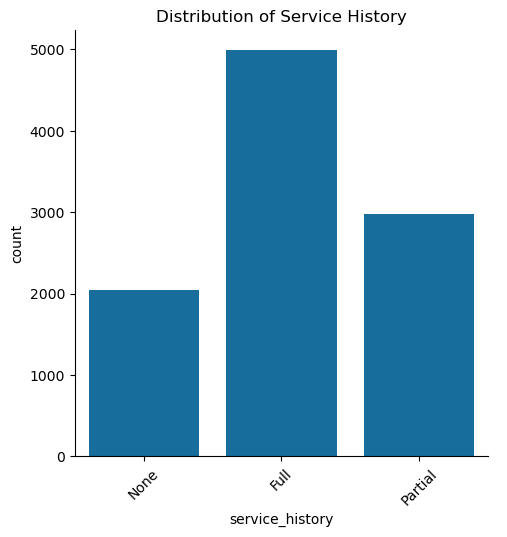

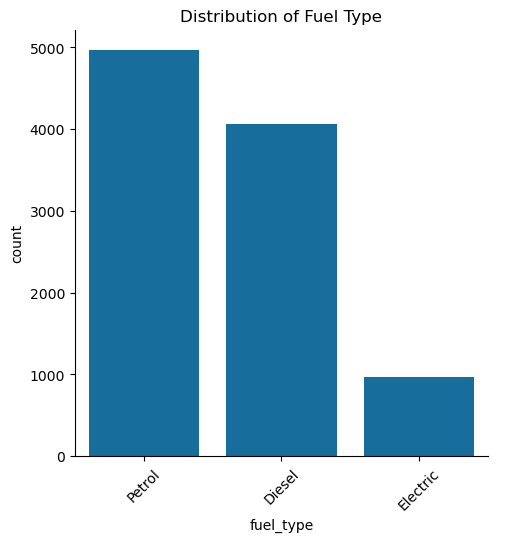

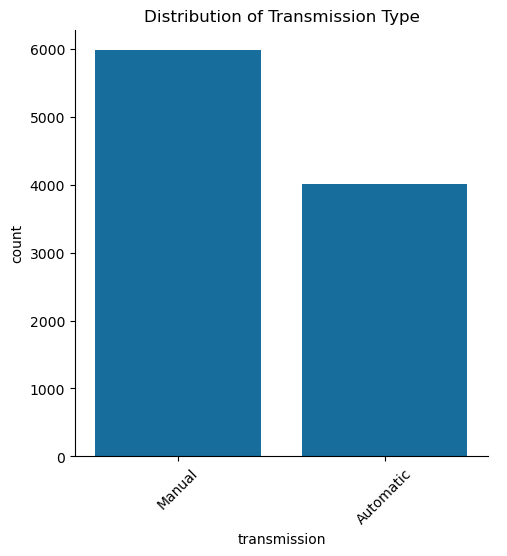

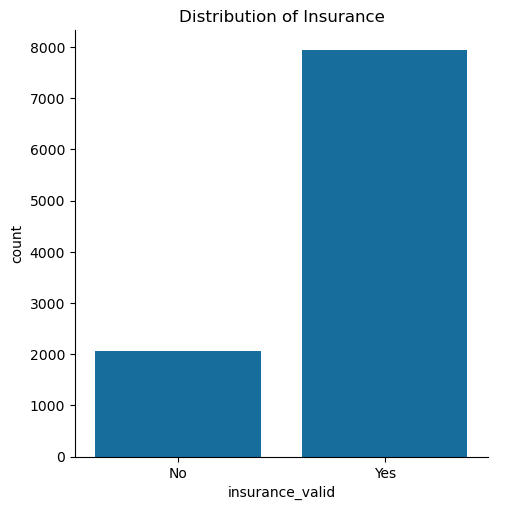

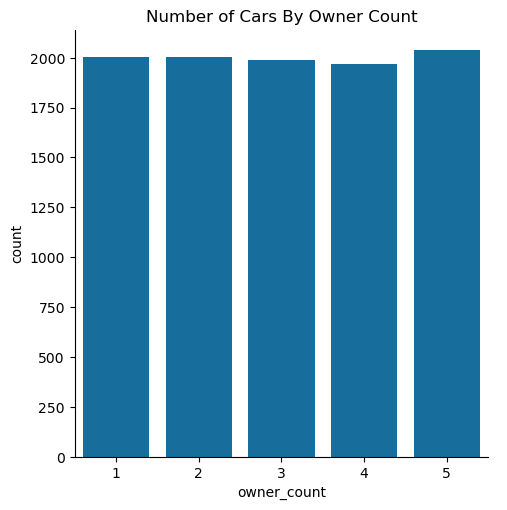

In [78]:
# Distributions of cateogrical variables
sns.set_palette("colorblind")

# service_history
ax = sns.catplot(data=df, x='service_history', kind='count')
ax.set(title='Distribution of Service History')
plt.xticks(rotation=45)
plt.show()

# fuel_type
ax = sns.catplot(data=df, x='fuel_type', kind='count')
ax.set(title='Distribution of Fuel Type')
plt.xticks(rotation=45)
plt.show()

# transmission
ax = sns.catplot(data=df, x='transmission', kind='count')
ax.set(title='Distribution of Transmission Type')
plt.xticks(rotation=45)
plt.show()

# insurance_valid
ax = sns.catplot(data=df, x='insurance_valid', kind='count')
ax.set(title='Distribution of Insurance')
plt.show()

# owner_count
# even tho owner count is numeric - we will treat it as categorial since it makes more sense to use a bar plot
ax = sns.catplot(data=df, x='owner_count', kind='count')
ax.set(title = 'Number of Cars By Owner Count')
plt.show()

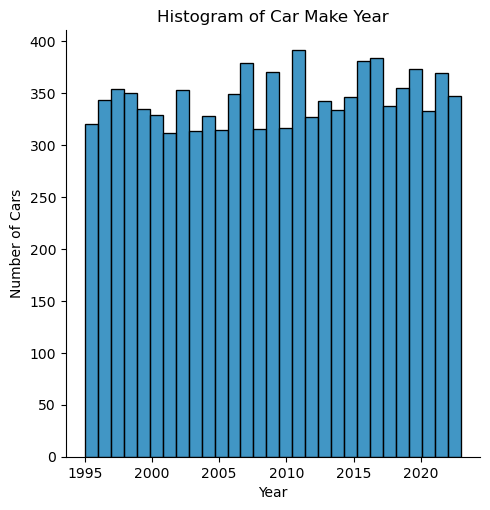

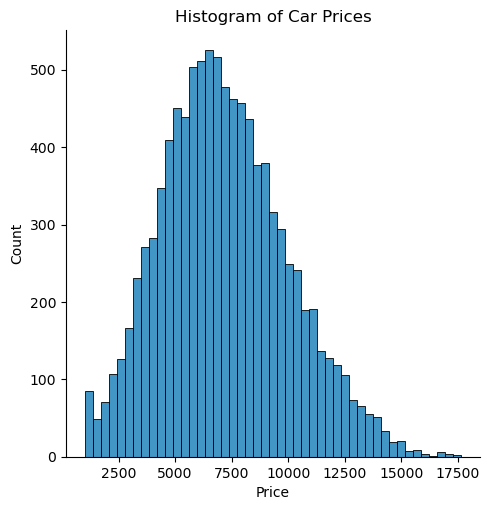

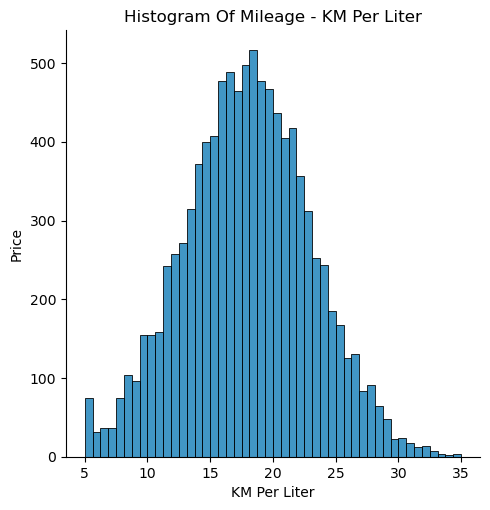

In [79]:
# Distributions of continuous variables

# make_year
ax = sns.displot(df, x='make_year', bins=29) # 29 bins since make year is between 1995-2023
ax.set(xlabel='Year', ylabel='Number of Cars', title='Histogram of Car Make Year')
plt.show()

# price_usd
ax = sns.displot(df, x='price_usd')
ax.set(xlabel='Price', ylabel='Count', title='Histogram of Car Prices')
plt.show()

# mileage_kmpl
ax = sns.displot(data=df, x='mileage_kmpl')
ax.set(xlabel='KM Per Liter', ylabel='Price', title='Histogram Of Mileage - KM Per Liter')
plt.show()

## Visualizing relationships

After we got a sense of how our variables are distributed, we can think of interesting relationships to examine.

It probably makes sense to think of car price as the focal variable of interest, so let's visualize relationships of *price_usd* with other variables that we think may impact the price


- The Relation Between Car km\l To Price.
- The Relation Between Car Make Year and Price.
- The Relation Between Car Engine Capacity and Make Year.

<Figure size 2000x1200 with 0 Axes>

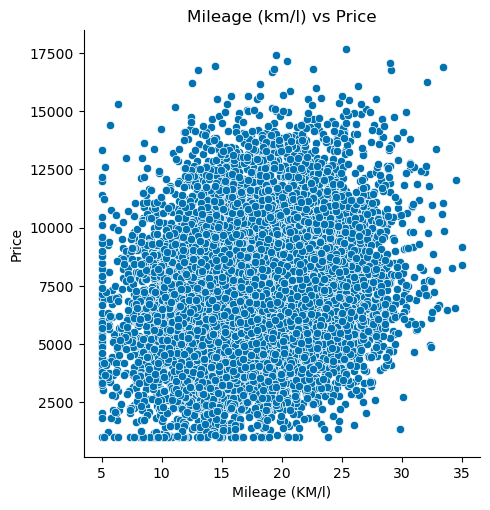

In [81]:
plt.figure(figsize=(20, 12))
sns.relplot(x="mileage_kmpl", y="price_usd", data=df)
plt.title('Mileage (km/l) vs Price')
plt.xlabel('Mileage (KM/l)')
plt.ylabel('Price')
plt.show()

- It seems we have no correlation between KM/l and car price

##### Since "car price per year" might yield diffrent results using diffrent methods,

##### we will create the Line Plot using Mean & Median for each year

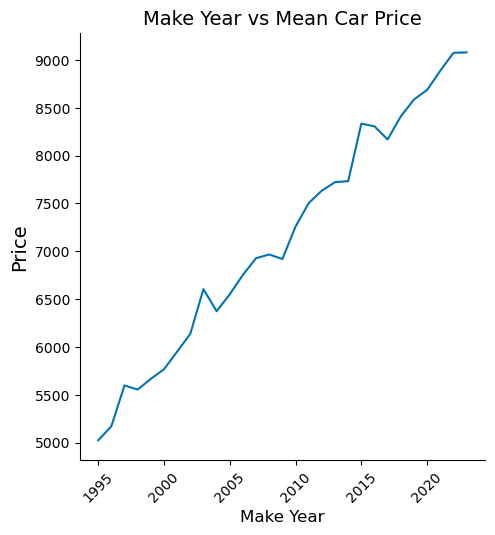

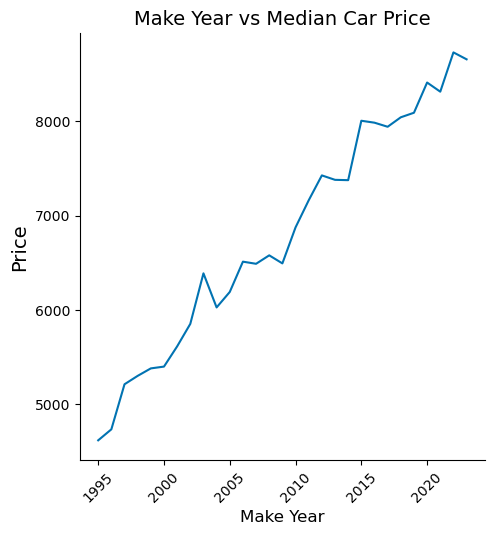

In [84]:
# calculate the Mean car price for each year
df_line_mean = df.groupby('make_year')['price_usd'].mean().reset_index()

# create a line plot of mean engine capacity by year
sns.relplot(x="make_year", y="price_usd", kind="line", data=df_line_mean)
plt.title('Make Year vs Mean Car Price', fontsize=14)
plt.xlabel('Make Year', fontsize=12)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# calculate the Median car price for each year
df_line_median = df.groupby('make_year')['price_usd'].median().reset_index()

# create a line plot of mean engine capacity by year
sns.relplot(x="make_year", y="price_usd", kind="line", data=df_line_median)
plt.title('Make Year vs Median Car Price', fontsize=14)
plt.xlabel('Make Year', fontsize=12)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45)
plt.show()

##### Again, since "engine capacity per year" might yield diffrent results using diffrent methods,

##### we will create the Line Plot using Mean & Median

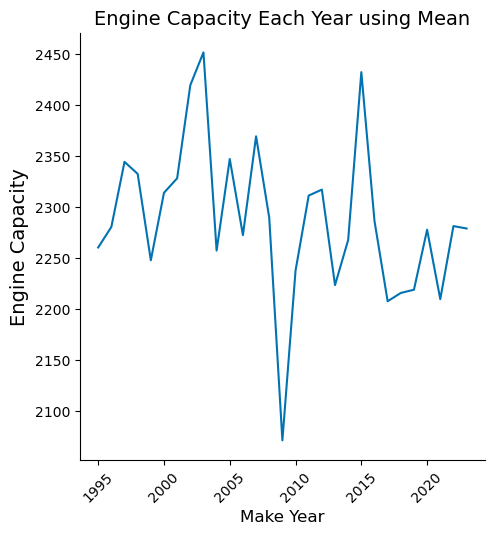

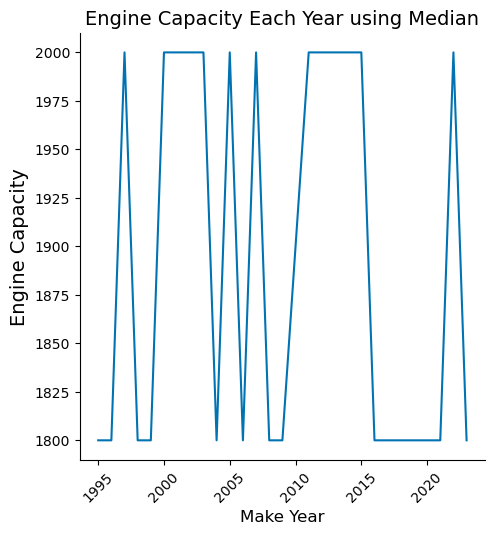

In [86]:
# calculate the Mean engine capacity per year
df_line_mean = df.groupby('make_year')['engine_cc'].mean().reset_index()

# create a line plot of Mean engine capacity per year
sns.relplot(x="make_year", y="engine_cc", kind="line", data=df_line_mean)
plt.title('Engine Capacity Each Year using Mean', fontsize=14)
plt.xlabel('Make Year', fontsize=12)
plt.ylabel('Engine Capacity', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# calculate the Median engine capacity per year
df_line_median = df.groupby('make_year')['engine_cc'].median().reset_index()

# create a line plot of Median engine capacity per year
sns.relplot(x="make_year", y="engine_cc", kind="line", data=df_line_median)
plt.title('Engine Capacity Each Year using Median', fontsize=14)
plt.xlabel('Make Year', fontsize=12)
plt.ylabel('Engine Capacity', fontsize=14)
plt.xticks(rotation=45)
plt.show()

## Statistical comparisons


### Fuel type, transmission, and price

Examine whether mean prices differ across fuel and transmission categories. These comparisons describe associations, not causal effects.


The comparisons examine equal versus unequal mean prices across the selected groups.


### Fuel type and mean price

Use 5,000 bootstrap resamples per fuel-type pair to estimate a 95% confidence interval for the difference in mean prices.


              Pair Observed Diff in Means 95% Confidence Interval  p-value
  Diesel vs Petrol                  27.25        [-85.56, 137.67]   0.6692
Diesel vs Electric               -2931.74    [-3115.76, -2741.44]   0.4888
Electric vs Petrol                2958.99      [2779.64, 3141.84]   0.5096


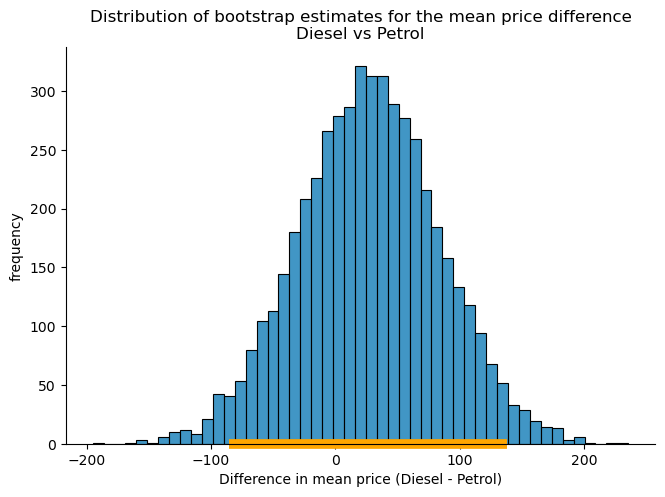

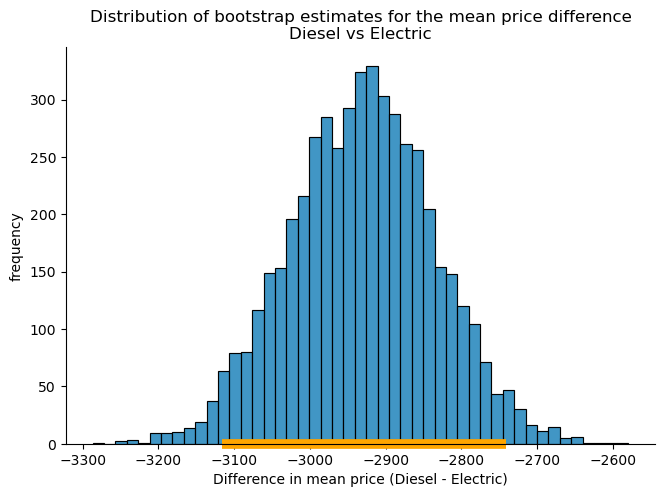

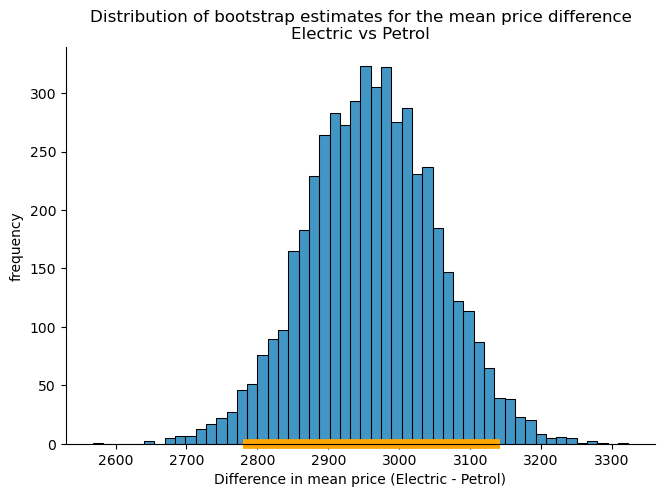

In [91]:
# Most of this code is from the lectures, with some simple adjustments

# function that returns the difference in averages of "column_name" grouping by "grouping_var"
def diff_of_avgs(df_in, column_name, grouping_var):
    grpby_var = df_in.groupby(grouping_var, observed=True)
    avgs = grpby_var[column_name].mean()
    # IMPORTANT: assumes df_in contains exactly TWO groups; order is the group order in avgs
    return avgs.iloc[1] - avgs.iloc[0]

def bootstrap_mean_difference(original_sample, column_name, grouping_var, num_replications):
    '''This function returns an array of bootstrapped differences between two sample averages:
      original_sample: df containing the original sample
      column_name: name of column containing the variable to average
      grouping_var: name of variable according to which to group
      num_replications: number of bootstrap samples'''
    original_sample_size = original_sample.shape[0]  # replicate with the same sample size
    original_sample_cols_of_interest = original_sample[[column_name, grouping_var]]
    bstrap_mean_diffs = np.empty(num_replications)
    for i in range(num_replications):
        # WITH REPLACEMENT
        bootstrap_sample = original_sample_cols_of_interest.sample(original_sample_size, replace=True)
        resampled_mean_diff = diff_of_avgs(bootstrap_sample, column_name, grouping_var)
        bstrap_mean_diffs[i] = resampled_mean_diff
    return bstrap_mean_diffs

# fuel-type pairs
pairs = [("Diesel", "Petrol"), ("Diesel", "Electric"), ("Electric", "Petrol")]

# run bootstrap for each pair
results = []  # collect results for each pair
NUM_REPS = 5000

for g1, g2 in pairs:
    # restrict to the two groups in this pair
    sub_df = df[df['fuel_type'].isin([g1, g2])].copy()

    # fixes order between fuel type
    sub_df['fuel_type'] = pd.Categorical(sub_df['fuel_type'], categories=[g2, g1], ordered=True)

    # observed difference
    obs_diff = diff_of_avgs(sub_df, 'price_usd', 'fuel_type')

    # bootstrap distribution of mean differences
    bstrap_diffs = bootstrap_mean_difference(
        original_sample=sub_df,
        column_name='price_usd',
        grouping_var='fuel_type',
        num_replications=NUM_REPS
    )

    # Get the endpoints of the 95% confidence interval
    left_end = np.percentile(bstrap_diffs, 2.5, method='higher')
    right_end = np.percentile(bstrap_diffs, 97.5, method='higher')

    # p-value calculation
    p_value = np.mean(np.abs(bstrap_diffs) >= np.abs(obs_diff))

    # Store results
    results.append({
        'Pair': f'{g1} vs {g2}',
        'Observed Diff in Means': f'{obs_diff:.2f}',
        '95% Confidence Interval': f'[{left_end:.2f}, {right_end:.2f}]',
        'p-value': p_value
    })

    # visualize results
    ax = sns.displot(bstrap_diffs, height=4.5, aspect=1.5)
    plt.hlines(y=0, xmin=left_end, xmax=right_end,
               colors='orange', linestyles='solid', lw=7, clip_on=False)
    ax.set(
        xlabel=f'Difference in mean price ({g1} - {g2})',
        ylabel='frequency',
        title=f'Distribution of bootstrap estimates for the mean price difference\n{g1} vs {g2}'
    )

# results summary
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

### Interpreting the saved confidence intervals

The Diesel–Petrol interval includes zero. The Diesel–Electric and Electric–Petrol intervals exclude zero, with higher average prices for electric cars in this dataset. These pairwise, unadjusted intervals describe associations and do not establish a causal effect.

Original p-value calculations are retained as coursework records and are not presented here as validated significance results.


##### Let's visualize the average car price per fuel type to see the difference more clearly

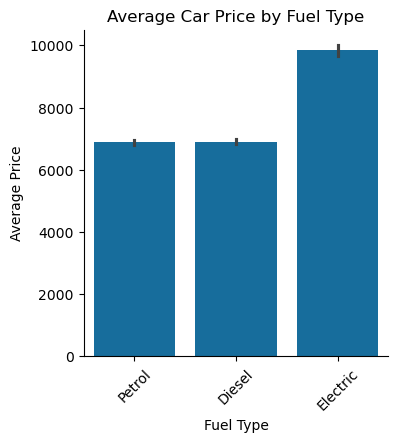

Electric cars average price: 9839.48

Non - Electric cars (Petrol and Diesel) average price: 6892.74 

There are 974 Electric cars out of 10000


In [94]:
ax = sns.catplot(data=df, x='fuel_type',y='price_usd',kind='bar',height=4,aspect=1)
ax.set(title='Average Car Price by Fuel Type', xlabel='Fuel Type', ylabel='Average Price')
plt.xticks(rotation=45)
plt.show()

# ממוצע מחיר של רכבים חשמליים בלבד
mean_electric = df[df['fuel_type'] == 'Electric']['price_usd'].mean()

# כמה רכבים חשמליים יש
sum_electric = df[df['fuel_type'] == 'Electric'].shape[0]

# ממוצע מחיר של רכבים שאינם חשמליים (Petrol או Diesel)
mean_non_electric = df[df['fuel_type'].isin(['Petrol', 'Diesel'])]['price_usd'].mean()

print(f"Electric cars average price: {mean_electric:.2f}")
print(f"\nNon - Electric cars (Petrol and Diesel) average price: {mean_non_electric:.2f} ")
print(f"\nThere are {sum_electric} Electric cars out of 10000")

Electric cars account for 974 of 10,000 records (9.74%). This share does not establish their prevalence in the wider market or explain the observed price difference.


### Transmission type and mean price


Compare mean prices of manual and automatic cars in the supplied dataset. The null hypothesis is equal population means; the alternative is unequal means.


Estimate a 95% bootstrap confidence interval for the mean-price difference between transmission categories.


Hypothesis Test Results:
         Comparison Observed Diff in Means (Automatic - Manual) 95% Confidence Interval P-value
Automatic vs Manual                                     $-15.80      [$-122.62, $95.71]  0.7900


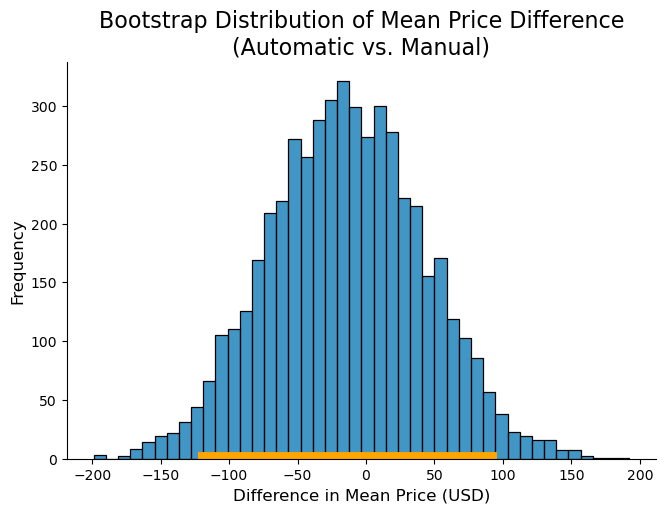

In [102]:
# הגדרת המשתנים
COLUMN_TO_TEST = 'price_usd'
GROUPING_VARIABLE = 'transmission'
GROUP_1 = 'Automatic'
GROUP_2 = 'Manual'
NUM_REPS = 5000

sub_df = df.copy()

# חישוב ההפרש בממוצעים
# הסדר הוא 'Automatic' - 'Manual'
obs_diff = diff_of_avgs(sub_df, COLUMN_TO_TEST, GROUPING_VARIABLE)

# הרצת סימולציית בוטסטראפ לקבלת התפלגות הפרשי הממוצעים
bstrap_diffs = bootstrap_mean_difference(
    original_sample=sub_df,
    column_name=COLUMN_TO_TEST,
    grouping_var=GROUPING_VARIABLE,
    num_replications=NUM_REPS
)

# חישוב רווח סמך של 95%
left_end = np.percentile(bstrap_diffs, 2.5)
right_end = np.percentile(bstrap_diffs, 97.5)

# חישוב p-value
# מכיוון שהשערת האפס היא שההפרש הוא 0, אנחנו בודקים את הסיכוי לקבל הפרש קיצוני כמו זה שצפינו
p_value = np.mean(np.abs(bstrap_diffs) >= np.abs(obs_diff))

# הדפסת התוצאות בטבלה
results = {
    'Comparison': f'{GROUP_1} vs {GROUP_2}',
    'Observed Diff in Means (Automatic - Manual)': f'${obs_diff:,.2f}',
    '95% Confidence Interval': f'[${left_end:,.2f}, ${right_end:,.2f}]',
    'P-value': f'{p_value:.4f}'
}
results_df = pd.DataFrame([results])
print("Hypothesis Test Results:")
print(results_df.to_string(index=False))

# ויזואליזציה
ax = sns.displot(bstrap_diffs, height=4.5, aspect=1.5)
plt.hlines(y=0, xmin=left_end, xmax=right_end,
            colors='orange', linestyles='solid', lw=10, label='95% Confidence Interval')

plt.title(f'Bootstrap Distribution of Mean Price Difference\n({GROUP_1} vs. {GROUP_2})', fontsize=16)
plt.xlabel(f'Difference in Mean Price (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Interpreting the saved confidence interval

The interval includes zero, so this comparison does not provide clear evidence of a mean-price difference. It does not establish that transmission has no relationship with price. Original code and output labels are preserved for later review.


##### Let's visualize the average car price per transmission type to see the results more clearly

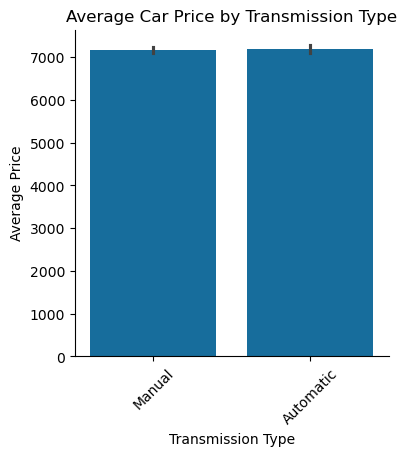

Manual cars average price: 7173.41

Automatic cars average price: 7189.21 

There are 5985 Manual cars out of 10000


In [107]:
ax = sns.catplot(data=df, x='transmission',y='price_usd',kind='bar',height=4,aspect=1)
ax.set(title='Average Car Price by Transmission Type', xlabel='Transmission Type', ylabel='Average Price')
plt.xticks(rotation=45)
plt.show()

# ממוצע מחיר של רכבים ידניים
mean_manual = df[df['transmission'] == 'Manual']['price_usd'].mean()

# כמה רכבים ידניים יש
sum_manual = df[df['transmission'] == 'Manual'].shape[0]

# ממוצע מחיר רכבים אוטומטיים
mean_auto = df[df['transmission'] == 'Automatic']['price_usd'].mean()

print(f"Manual cars average price: {mean_manual:.2f}")
print(f"\nAutomatic cars average price: {mean_auto:.2f} ")
print(f"\nThere are {sum_manual} Manual cars out of 10000")

## Price-bracket classification


## Classification

The most immediate classification task that comes to mind is to classify the price of a car - either "Budget", "Mid-Range" or "Luxury"

We'll need to choose features for our classification task, but we do not want to choose them based on the test set, so we should split our data and  put aside a test set before we do any feature selection.
Yet, we also need to do a bit of preprocessing first, handling categorical variables.

- There are no missing values

#### First, let's make price classes, and get rid of the original *price_usd* to prevent leakage

In [111]:
# creates 3 balanced bins from the continuous price
# 33% percentile will get 0 - meaning *low*
# 33% - 66% percentile will get 1 - meaning *average*
# 66% - 100% percentile will get 2 - meaning *expansive*
# all as integers, as this what's KNN expects
df['price_bracket'] = pd.qcut(df['price_usd'], q=3, labels=[0, 1, 2]).astype(int)

# Get ranges and amounts
ranges = pd.qcut(df['price_usd'], q=3).cat.categories
counts = df['price_bracket'].value_counts().sort_index()

print(f"Budget price range [{ranges[0].left:.0f}, {ranges[0].right:.0f}] - {counts[0]} cars")
print(f"Mid-Range price range [{ranges[1].left:.0f}, {ranges[1].right:.0f}] - {counts[1]} cars")
print(f"Expensive price range [{ranges[2].left:.0f}, {ranges[2].right:.0f}] - {counts[2]} cars")


# remove price_usd column to prevent leakage
df = df.drop(columns=['price_usd'])
target = 'price_bracket'

Budget price range [1000, 5826] - 3333 cars
Mid-Range price range [5826, 8225] - 3333 cars
Expensive price range [8225, 17648] - 3334 cars


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   brand               10000 non-null  object 
 6   transmission        10000 non-null  object 
 7   color               10000 non-null  object 
 8   service_history     10000 non-null  object 
 9   accidents_reported  10000 non-null  int64  
 10  insurance_valid     10000 non-null  object 
 11  price_bracket       10000 non-null  int32  
dtypes: float64(1), int32(1), int64(4), object(6)
memory usage: 898.6+ KB


## Our categorial features are

- *fuel_type*
- *brand*
- *transmission*
- *color*
- *insurance_valid*
- *service_history*

#### Since all of the features but *service_history* are Nominal categories,

#### we will use pd.get_dummies for all but *service_history* (which is Ordinal category),

#### for *service_history* we will use pandas.replace().

In [16]:
# one-hot encoding
encoded_df = pd.get_dummies(df,
                                columns=['fuel_type', 'brand', 'transmission', 'color', 'insurance_valid'], drop_first=True)
encoded_df.head()

,make_year,mileage_kmpl,engine_cc,owner_count,service_history,accidents_reported,price_bracket,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,...,brand_Tesla,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes
0,2001,8.17,4000,4,None,0,2,False,True,True,...,False,False,False,True,False,False,False,False,True,False
1,2014,17.59,1500,4,None,0,1,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,2023,18.09,2500,5,Full,1,2,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2009,11.28,800,1,Full,0,1,False,True,False,...,False,False,False,True,True,False,False,False,False,True
4,2005,12.23,1000,2,Full,0,0,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [17]:
encoded_df['service_history'] = encoded_df['service_history'].map({'None': 1, 'Partial': 2, 'Full': 3})
encoded_df["service_history"] = encoded_df["service_history"].astype(int)
encoded_df.head()

,make_year,mileage_kmpl,engine_cc,owner_count,service_history,accidents_reported,price_bracket,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,...,brand_Tesla,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes
0,2001,8.17,4000,4,1,0,2,False,True,True,...,False,False,False,True,False,False,False,False,True,False
1,2014,17.59,1500,4,1,0,1,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,2023,18.09,2500,5,3,1,2,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2009,11.28,800,1,3,0,1,False,True,False,...,False,False,False,True,True,False,False,False,False,True
4,2005,12.23,1000,2,3,0,0,False,True,False,...,False,False,False,False,False,False,True,False,False,True


### Now we need to
- Split the dataset to train and test sets (80% - train, 20% - test)
- Scale our features between themselves

In [18]:
from sklearn.model_selection import train_test_split

# shuffle the dataframe first
encoded_df = encoded_df.sample(frac=1)

# make sure price exists
assert 'price_bracket' in encoded_df.columns

Y = encoded_df['price_bracket']
X = encoded_df.drop(columns=['price_bracket'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20)

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

#### Feature selection

We would like to use the features that are useful for distinguishing between the classes, because if we include features that aren't we might add noise to our classifier.

We will examine the correlation of features with our target variable which is the *price*. Features that correlate strongly with the class, whether negatively or positively, are a good match.

We will visualize correlations using a heatmap.

In [20]:
train_data = pd.concat([X_train, Y_train], axis=1)
train_data.corr()

,make_year,mileage_kmpl,engine_cc,owner_count,service_history,accidents_reported,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,brand_Ford,...,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes,price_bracket
make_year,1.000000,-0.015477,-0.019181,-0.024134,0.004708,-0.007263,-0.017967,0.023310,0.007728,-0.005023,...,-0.001604,0.000628,0.009329,0.009942,0.009159,0.003632,-0.026431,0.002397,0.005717,0.391700
mileage_kmpl,-0.015477,1.000000,-0.010683,-0.007696,-0.007206,0.001739,0.003085,-0.000632,-0.004153,-0.003437,...,-0.006989,-0.004670,0.001465,0.008249,-0.006655,-0.013752,-0.004845,-0.012878,0.014282,0.183056
engine_cc,-0.019181,-0.010683,1.000000,-0.004825,0.013428,-0.007759,-0.007555,-0.009376,0.004619,0.022312,...,-0.010394,0.012394,0.006948,0.008294,0.011445,0.003927,0.001292,-0.021817,-0.007704,0.609586
owner_count,-0.024134,-0.007696,-0.004825,1.000000,-0.024724,-0.014288,-0.012068,0.013725,-0.008536,0.009833,...,-0.002526,0.004631,0.008755,0.003924,-0.009228,-0.006851,0.004412,0.002506,0.000426,-0.241352
service_history,0.004708,-0.007206,0.013428,-0.024724,1.000000,0.023891,0.008511,0.008830,-0.021357,-0.021654,...,0.019590,-0.001843,0.018348,-0.021294,-0.010580,0.017935,-0.004752,0.005620,-0.000765,0.014706
accidents_reported,-0.007263,0.001739,-0.007759,-0.014288,0.023891,1.000000,0.011513,-0.011203,-0.015213,-0.010918,...,-0.005402,-0.015816,-0.007075,0.013781,0.003739,-0.011188,-0.013120,0.000364,-0.025651,-0.002786
fuel_type_Electric,-0.017967,0.003085,-0.007555,-0.012068,0.008511,0.011513,1.000000,-0.324198,-0.007123,0.015735,...,-0.020405,-0.005152,0.001060,-0.008688,-0.020015,0.026687,-0.003982,0.010544,-0.000528,0.258261
fuel_type_Petrol,0.023310,-0.000632,-0.009376,0.013725,0.008830,-0.011203,-0.324198,1.000000,0.001274,0.000660,...,0.001154,0.019269,0.001737,0.011655,-0.008390,-0.012353,0.019076,-0.014355,-0.003555,-0.092923
brand_Chevrolet,0.007728,-0.004153,0.004619,-0.008536,-0.021357,-0.015213,-0.007123,0.001274,1.000000,-0.107568,...,-0.109228,-0.115263,-0.003112,0.003172,0.007024,0.014075,-0.008084,-0.003935,-0.005358,0.003812
brand_Ford,-0.005023,-0.003437,0.022312,0.009833,-0.021654,-0.010918,0.015735,0.000660,-0.107568,1.000000,...,-0.104581,-0.110360,-0.016854,-0.008601,-0.007262,0.002406,-0.018846,0.020295,0.002220,0.014976


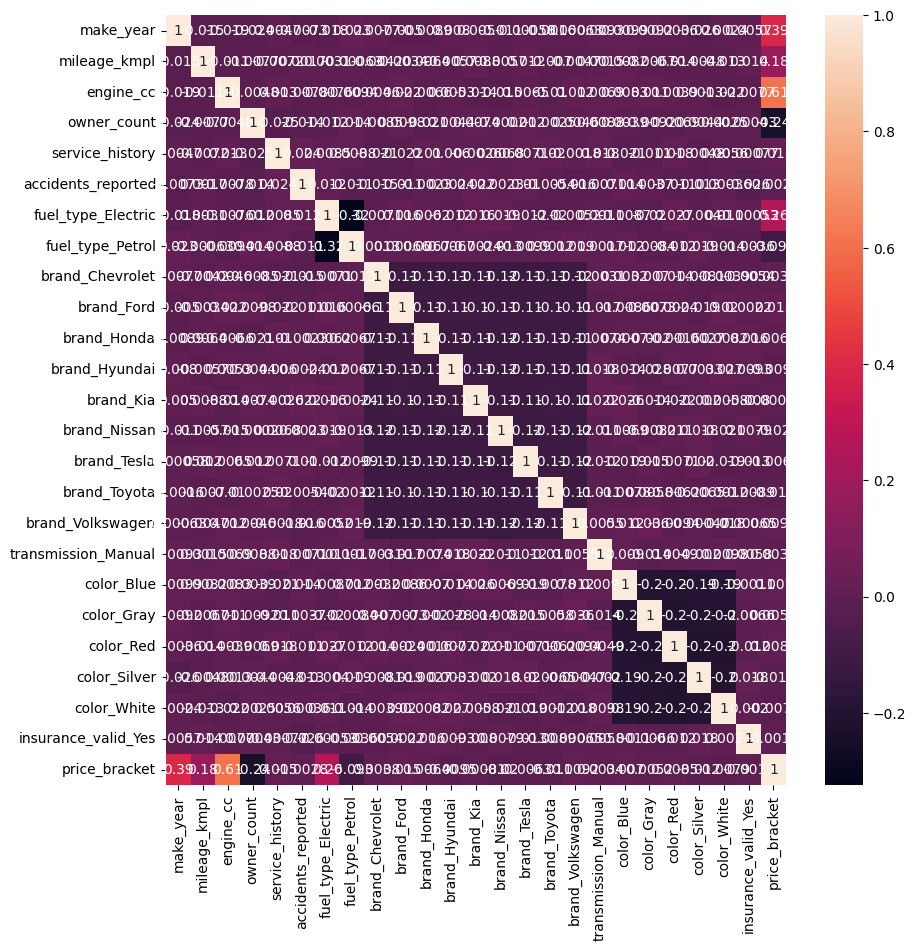

In [21]:
# compute correlation between each pair of variables in data frame
correlations = train_data.corr()

# plot heat map
plt.figure(figsize=(10,10))
sns.heatmap(correlations, annot=True)
plt.show()

The correlation heatmap is dense. In the original analysis, color was removed before a second feature-selection pass; brand was initially retained as a candidate. Visual density alone does not demonstrate statistical noise.


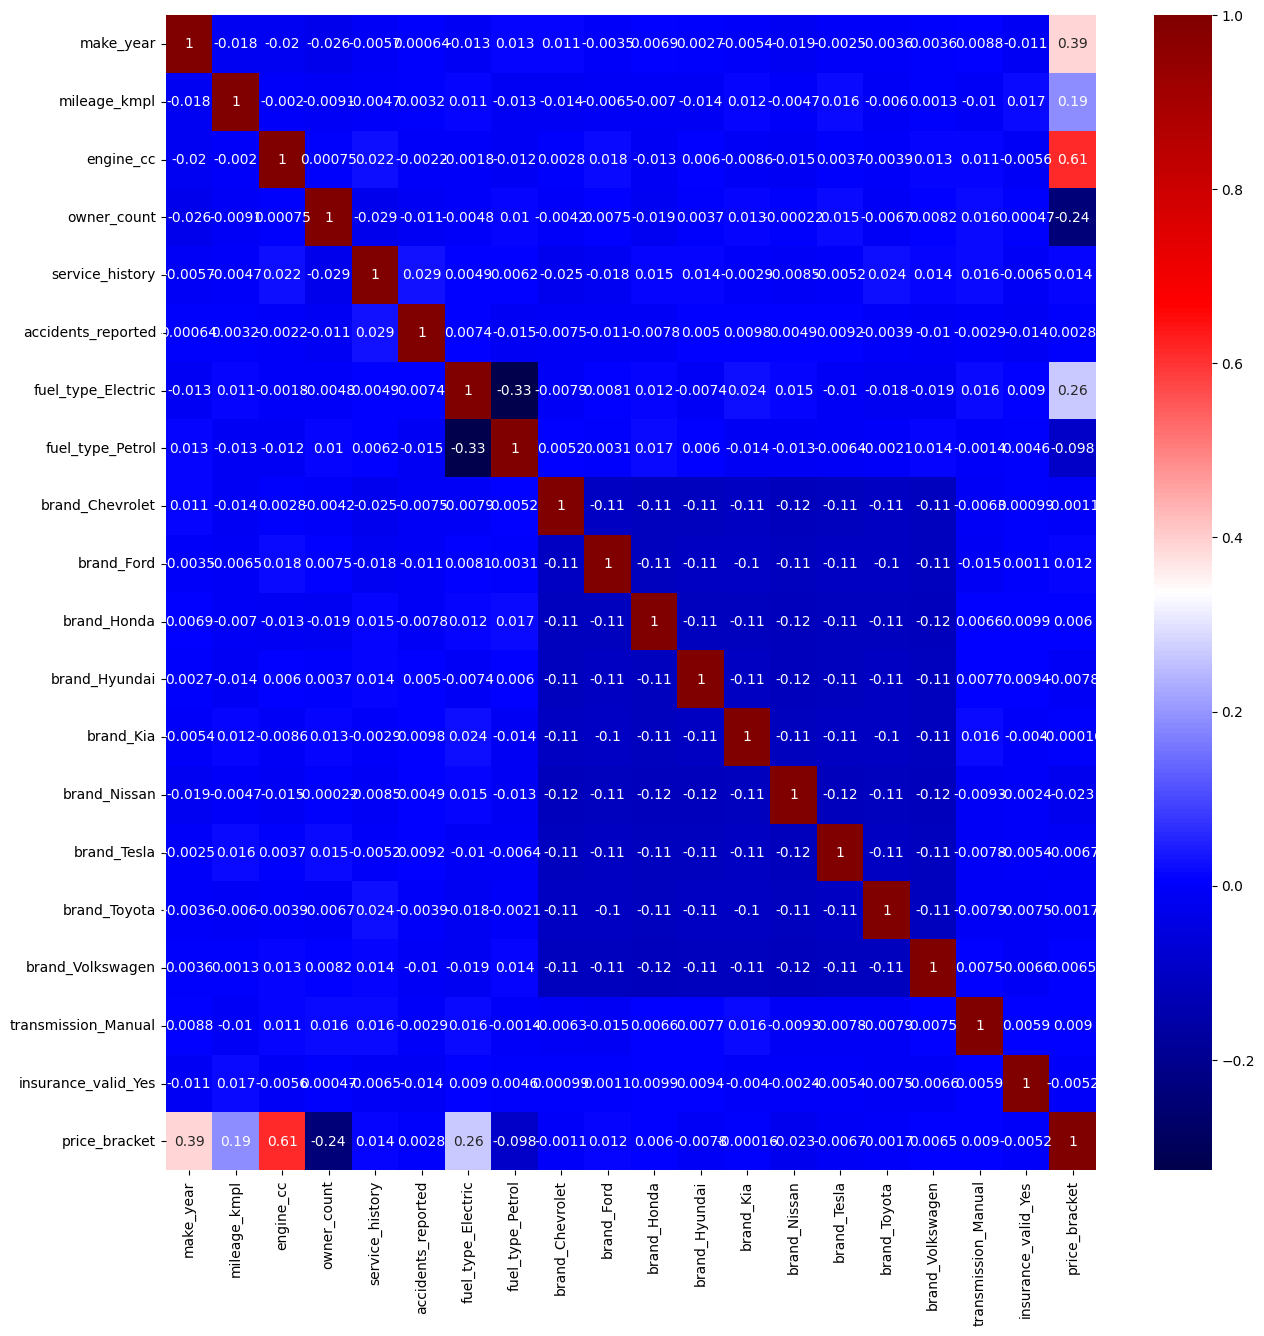

In [22]:
# get rid of *color* and do all over
encoded_df = df.drop(columns=['color'])

encoded_df = pd.get_dummies(encoded_df,
                                columns=['fuel_type', 'brand', 'transmission', 'insurance_valid'], drop_first=True)

encoded_df['service_history'] = encoded_df['service_history'].map({'None': 1, 'Partial': 2, 'Full': 3})
encoded_df["service_history"] = encoded_df["service_history"].astype(int)

# shuffle the dataframe
encoded_df = encoded_df.sample(frac=1)

# make sure price_usd exists
assert 'price_bracket' in encoded_df.columns

Y = encoded_df['price_bracket']
X = encoded_df.drop(columns=['price_bracket'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20)


scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)


train_data = pd.concat([X_train, Y_train], axis=1)


# compute correlation between each pair of variables in data frame
correlations = train_data.corr()

# plot heat map
plt.figure(figsize=(15,15))
sns.heatmap(correlations, annot=True, cmap="seismic")
plt.show()

In [23]:
correlations.reindex(correlations["price_bracket"].abs().sort_values().index)["price_bracket"] # ordered by absolute value

,price_bracket
brand_Kia,-0.000159
brand_Chevrolet,-0.001130
brand_Toyota,-0.001725
accidents_reported,0.002811
insurance_valid_Yes,-0.005186
brand_Honda,0.005973
brand_Volkswagen,0.006470
brand_Tesla,-0.006672
brand_Hyundai,-0.007805
transmission_Manual,0.009002


The next classifier uses the six features with the strongest absolute training-set correlations with the ordinal price bracket. This was the coursework selection rule, not proof that other variables are irrelevant.


In [24]:
# First, let's keep only the variables we're interested in (for both the train and test sets)
# code from lecture
selected_features = ['engine_cc', 'make_year', 'owner_count', 'mileage_kmpl', 'fuel_type_Electric',
                     'fuel_type_Petrol']

X_train = X_train[selected_features]
display(X_train)

X_test = X_test[selected_features]
X_test

,engine_cc,make_year,owner_count,mileage_kmpl,fuel_type_Electric,fuel_type_Petrol
8814,2000,1997,3,5.00,False,True
5061,2000,1997,3,22.98,False,False
2363,5000,2014,2,18.90,False,True
3105,1800,2013,1,9.17,False,True
8456,5000,1995,1,19.03,False,False
...,...,...,...,...,...,...
50,800,1997,1,19.60,False,True
4376,1800,2018,1,19.23,False,False
5596,1000,2004,3,17.64,False,False
508,1800,2016,4,13.94,False,False


,engine_cc,make_year,owner_count,mileage_kmpl,fuel_type_Electric,fuel_type_Petrol
2210,3000,2014,3,12.49,False,False
519,1200,2022,1,18.28,False,True
923,1000,2012,3,21.31,True,False
8004,2000,2022,1,15.34,False,False
5837,2000,1997,2,20.99,False,False
...,...,...,...,...,...,...
6389,4000,2020,3,21.16,False,True
7356,3000,2006,3,17.47,False,True
1857,1200,2008,5,21.35,False,True
683,1800,2019,5,13.85,False,False


In [25]:
# Second, we need to scale the variables to be on the same scale
# We choose to standardize using z-scores because KNN is a distance-based algorithm,
# and without standardization, features with larger numeric ranges would dominate the distance metric.
# By converting each feature to have a mean of 0 and a standard deviation of 1, we ensure that all features
# contribute equally to the neighbor search, improving the fairness and reliability of the model’s predictions.
from sklearn.preprocessing import StandardScaler
df_columns = X_train.columns
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)

scaled_X_test = scaler.transform(X_test)

scaled_df = pd.DataFrame(scaled_X_train, columns=df_columns)
scaled_df.describe()

,engine_cc,make_year,owner_count,mileage_kmpl,fuel_type_Electric,fuel_type_Petrol
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,-1.207923e-16,-8.227641e-15,-6.217249e-17,-6.004086e-16,2.309264e-17,-5.684342e-17
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.151531e+00,-1.686695e+00,-1.412387e+00,-2.576860e+00,-3.286841e-01,-9.945150e-01
25%,-8.430011e-01,-8.533331e-01,-7.081302e-01,-6.854218e-01,-3.286841e-01,-9.945150e-01
50%,-2.259406e-01,-1.997093e-02,-3.873413e-03,7.707710e-03,-3.286841e-01,-9.945150e-01
75%,5.453851e-01,8.133913e-01,7.003834e-01,6.769705e-01,-3.286841e-01,1.005515e+00
max,2.088036e+00,1.646753e+00,1.404640e+00,3.389822e+00,3.042435e+00,1.005515e+00


Highest accuracy is obtained for k = 24 and equals 0.7651249999999999


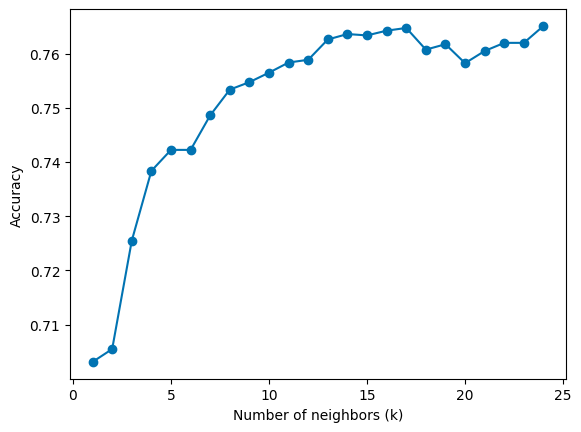

In [26]:
# Now, we can run 10-fold CV to find optimal k - using only the training data
# code from lecture
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

mean_cv_scores = []
k_list = range(1, 25)
for nn in k_list:
    knn_cv = KNeighborsClassifier(n_neighbors=nn)
    cv_scores = cross_val_score(knn_cv, scaled_X_train, Y_train, cv=10)
    mean_cv_scores.append(cv_scores.mean())

# output results
best_k = mean_cv_scores.index(max(mean_cv_scores))+1 # gets index of best performing k and adds 1
print('Highest accuracy is obtained for k =', best_k, 'and equals', max(mean_cv_scores))
plt.plot(k_list, mean_cv_scores, '-o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Accuracy');

In [27]:
# Last, we need to retrain our chosen kNN on the whole training data and test its accuracy on the test data
# code from lecture
# some modifciations were made to adjust to 3 variables and not binary (in the confusion matrix, precision and recall calculation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

knn_classifier = KNeighborsClassifier(n_neighbors=best_k)
knn_classifier.fit(scaled_X_train, Y_train)
print('accuracy of the classifier is', knn_classifier.score(scaled_X_test, Y_test))

# Compute a confusion matrix
predictions = knn_classifier.predict(X=scaled_X_test) # get the classifier's predictions
print('confusion matrix: \n', confusion_matrix(y_true=Y_test, y_pred=predictions, labels=[0, 1, 2])) # rows are true values, columns are predicted values

# Compute precision and recall, using average of 3 classes
print('precision: ', precision_score(y_true=Y_test, y_pred=predictions, average='macro'))
print('recall: ', recall_score(y_true=Y_test, y_pred=predictions, average='macro'))

accuracy of the classifier is 0.764
confusion matrix: 
 [[526 132   2]
 [ 98 486  77]
 [  6 157 516]]
precision:  0.7764147666234953
recall:  0.764053469530956


### Comparing a smaller feature set

Compare the six-feature classifier with a four-feature variant using engine size, make year, owner count, and the electric-fuel indicator.


In [28]:
# Again, let's keep only the variables we're interested in (for both the train and test sets)
# Now we will be using only four features that has the highest correlation
selected_features = ['engine_cc', 'make_year', 'owner_count', 'fuel_type_Electric']

X_train = X_train[selected_features]
display(X_train)

X_test = X_test[selected_features]
X_test

,engine_cc,make_year,owner_count,fuel_type_Electric
8814,2000,1997,3,False
5061,2000,1997,3,False
2363,5000,2014,2,False
3105,1800,2013,1,False
8456,5000,1995,1,False
...,...,...,...,...
50,800,1997,1,False
4376,1800,2018,1,False
5596,1000,2004,3,False
508,1800,2016,4,False


,engine_cc,make_year,owner_count,fuel_type_Electric
2210,3000,2014,3,False
519,1200,2022,1,False
923,1000,2012,3,True
8004,2000,2022,1,False
5837,2000,1997,2,False
...,...,...,...,...
6389,4000,2020,3,False
7356,3000,2006,3,False
1857,1200,2008,5,False
683,1800,2019,5,False


In [29]:
# Second, we need to scale the variables to be on the same scale
from sklearn.preprocessing import StandardScaler
df_columns = X_train.columns
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)

scaled_X_test = scaler.transform(X_test)

scaled_df = pd.DataFrame(scaled_X_train, columns=df_columns)
scaled_df.describe()

,engine_cc,make_year,owner_count,fuel_type_Electric
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,-1.207923e-16,-8.227641e-15,-6.217249e-17,2.309264e-17
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.151531e+00,-1.686695e+00,-1.412387e+00,-3.286841e-01
25%,-8.430011e-01,-8.533331e-01,-7.081302e-01,-3.286841e-01
50%,-2.259406e-01,-1.997093e-02,-3.873413e-03,-3.286841e-01
75%,5.453851e-01,8.133913e-01,7.003834e-01,-3.286841e-01
max,2.088036e+00,1.646753e+00,1.404640e+00,3.042435e+00


Highest accuracy is obtained for k = 20 and equals 0.7403750000000001


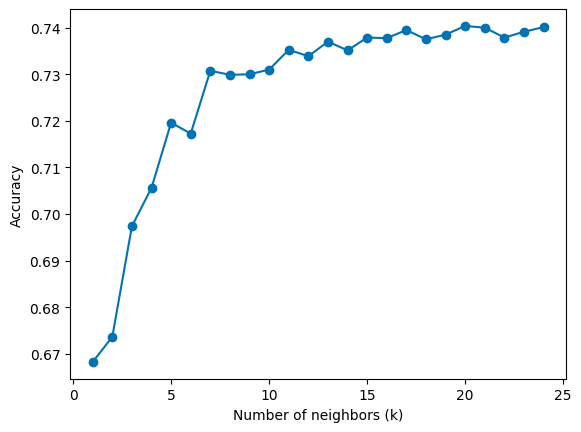

In [30]:
# Now, we can run 10-fold CV to find optimal k - using only the training data
# code from lecture
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

mean_cv_scores = []
k_list = range(1, 25)
for nn in k_list:
    knn_cv = KNeighborsClassifier(n_neighbors=nn)
    cv_scores = cross_val_score(knn_cv, scaled_X_train, Y_train, cv=10)
    mean_cv_scores.append(cv_scores.mean())

# output results
best_k = mean_cv_scores.index(max(mean_cv_scores))+1 # gets index of best performing k and adds 1
print('Highest accuracy is obtained for k =', best_k, 'and equals', max(mean_cv_scores))
plt.plot(k_list, mean_cv_scores, '-o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Accuracy');

In [31]:
# Last, we need to retrain our chosen kNN on the whole training data and test its accuracy on the test data
# code from lecture
# some modifciations were made to adjust to 3 variables and not binary (in the confusion matrix, precision and recall calculation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

knn_classifier = KNeighborsClassifier(n_neighbors=best_k)
knn_classifier.fit(scaled_X_train, Y_train)
print('accuracy of the classifier is', knn_classifier.score(scaled_X_test, Y_test))

# Compute a confusion matrix
predictions = knn_classifier.predict(X=scaled_X_test) # get the classifier's predictions
print('confusion matrix: \n', confusion_matrix(y_true=Y_test, y_pred=predictions, labels=[0, 1, 2])) # rows are true values, columns are predicted values

# Compute precision and recall, using average of 3 classes
print('precision: ', precision_score(y_true=Y_test, y_pred=predictions, average='macro'))
print('recall: ', recall_score(y_true=Y_test, y_pred=predictions, average='macro'))

accuracy of the classifier is 0.738
confusion matrix: 
 [[533 124   3]
 [133 424 104]
 [  7 153 519]]
precision:  0.7419666407541756
recall:  0.7377958181652989


## Recorded results

| Model | Selected k | Mean 10-fold CV accuracy | Test accuracy |
| --- | ---: | ---: | ---: |
| Six features | 24 | 76.51% | 76.4% |
| Four features | 20 | 74.04% | 73.8% |

The six-feature model had higher accuracy in the saved run. Computation time was not measured, so no speed advantage is claimed for the smaller model. These are original coursework outputs, not newly reproduced results or a production benchmark.
